In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from IPython.display import display, HTML

base_folder = ".."

## Topologies

In [2]:
def read_topology(topology_name):
    print(f"Topology name: {topology_name}")
    df = pd.read_csv(f"{base_folder}/resources/env/{topology_name}.txt", delimiter=";")
    display(HTML(df.to_html()))
        
read_topology("multi")
read_topology("single")

Topology name: multi


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,32,3.20,2048,1,256,32
1,B01,B01,48,2.93,1256,6,64,8
2,C01,C01,32,3.20,2048,2,128,16


Topology name: single


,ClusterID,ClusterName,Cores,Speed,Memory,numberOfHosts,memoryCapacityPerHost,coreCountPerHost
0,A01,A01,16,3.2,1280,1,1280,16


## Failure

In [3]:
def milli_to_day(inp):
    return timedelta(milliseconds=inp)


def read_failure(failure_name):
    print(f"Failure name: {failure_name}")
    df = pd.read_csv(f"{base_folder}/resources/failure_traces/{failure_name}.csv", delimiter=",")
    
    df["start_day"] = df["start"].apply(milli_to_day)
    df["duration_day"] = df["duration"].apply(milli_to_day)
    df["end_day"] = df["start_day"] + df["duration_day"]
    
    display(HTML(df.to_html()))
    return df
        
failure_trace = read_failure("two_failures")

Failure name: two_failures


,start,duration,intensity,start_day,duration_day,end_day
0,86400000,86400000,0.6,1 days,1 days,2 days
1,345600000,86400000,0.6,4 days,1 days,5 days


## Traces

In [4]:
df_trace = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/trace.parquet")
df_trace.head()

,id,timestamp,duration,cpu_count,cpu_usage
0,1019,2013-08-12 13:40:46+00:00,300000,1,0.000000
1,1019,2013-08-12 13:45:46+00:00,300000,1,11.703998
2,1019,2013-08-12 13:55:46+00:00,600000,1,0.000000
3,1019,2013-08-12 14:00:46+00:00,300000,1,11.703998
4,1019,2013-08-12 14:15:46+00:00,900000,1,0.000000


In [5]:
df_meta = pd.read_parquet(f"{base_folder}/resources/bitbrains-small/trace/meta.parquet")
df_meta.head()

,id,start_time,stop_time,cpu_count,cpu_capacity,mem_capacity
0,1019,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2926.000135,181352
1,1023,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999560,260096
2,1026,2013-08-12 13:35:46+00:00,2013-09-11 13:39:58+00:00,1,2925.999717,249972
3,1052,2013-08-29 14:38:12+00:00,2013-09-05 07:09:07+00:00,1,2926.000107,131245
4,1073,2013-08-21 11:07:12+00:00,2013-09-11 13:39:58+00:00,1,2599.999649,179306


# Lets run this in OpenDC!

## Load Resulting Files

In [6]:
def get_output(failure_trace, check_time, check_wait):
    output_folder = f"{base_folder}/output"

    df_host = pd.read_parquet(f"{output_folder}/{failure_trace}/{check_time}/{check_wait}/host.parquet")
    df_server = pd.read_parquet(f"{output_folder}/{failure_trace}/{check_time}/{check_wait}/server.parquet")
    df_service = pd.read_parquet(f"{output_folder}/{failure_trace}/{check_time}/{check_wait}/service.parquet")

    def add_absolute_timestamp(df, start_dt):
        df["absolute_timestamp"] = start_dt + (df["timestamp"] - df["timestamp"].min())

    add_absolute_timestamp(df_host, df_meta["start_time"].min())
    add_absolute_timestamp(df_server, df_meta["start_time"].min())
    add_absolute_timestamp(df_service, df_meta["start_time"].min())

    return df_host, df_server, df_service

## Determine worktime

In [7]:
def get_opendc_worktime(df, server_name):
    df = df[df["server_name"] == server_name].reset_index()
    df = df[df["host_id"].notnull()]

    if (len(df) == 0):
        print("server has not been run")
        return None
    
    df["diff"] = df.uptime.diff()
    
    uptime_changes = df[df["diff"] != 0]
    
    first_sample = df[df["uptime"] > 0].min()
    start_server = first_sample.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(first_sample.uptime))
    
    
    # This means the server was suspended due to failure
    if len(uptime_changes) == 3:
        start_suspend = uptime_changes.iloc[1].timestamp.to_pydatetime().replace(tzinfo=None)
        
        end_suspend = uptime_changes.iloc[2]
        end_suspend = end_suspend.timestamp.to_pydatetime().replace(tzinfo=None) - \
                        timedelta(milliseconds=int(end_suspend.uptime))
        
        end_server = df.timestamp.max().to_pydatetime().replace(tzinfo=None)
        first_worktime = start_suspend - start_server 
        second_worktime = end_server - end_suspend
        total_worktime = first_worktime + second_worktime
        
    else:
        end_server = df.timestamp.max().to_pydatetime().replace(tzinfo=None)
        total_worktime = end_server - start_server
        
    return total_worktime

def get_workload_data(df_meta, server_name):
    df_meta_filtered = df_meta[df_meta["id"] == server_name].iloc[0]
    return df_meta_filtered["stop_time"].to_pydatetime().replace(tzinfo=None) \
            - df_meta_filtered["start_time"].to_pydatetime().replace(tzinfo=None)

def compare_worktime(df_meta, df_server, server_name):
    opendc_worktime = get_opendc_worktime(df_server, server_name)
    
    if opendc_worktime == None:
        return None
    
    required_worktime = get_workload_data(df_meta, server_name)
    
    return opendc_worktime - required_worktime 


def get_delay(failure_trace, check_time, check_wait):
    df_host, df_server, df_service = get_output(failure_trace, check_time, check_wait)

    deltas = []

    for s in df_server.server_name.unique():
        deltas.append(compare_worktime(df_meta, df_server, s))

    return deltas

NameError: name 'check_time' is not defined

In [ ]:
for check_wait in check_waits:
    
    delays = get_delay(failure_trace, check_time, check_wait)

    print(f"delay for {check_wait = }: {np.mean(delays)}")

In [ ]:
failure_trace = "no_failure"
check_time = 300_000
check_waits = []

for file_name in os.listdir(f"{base_folder}/output/{failure_trace}/{check_time}"):
    check_waits.append(int(file_name))

check_waits.sort()

def get_runtime(failure_trace, check_time, check_wait):
    df_host, df_server, df_service = get_output(failure_trace, check_time, check_wait)


    return df_service.timestamp.max() - df_service.timestamp.min()

runtimes = []
labels = []

for check_wait in check_waits:
    
    runtime = get_runtime(failure_trace, check_time, check_wait)

    print(f"runtime for {str(timedelta(milliseconds=check_wait))}: {runtime}")

    runtimes.append(runtime / timedelta(milliseconds=1))


runtime for 0:30:00: 104 days 23:40:00
runtime for 1:00:00: 97 days 11:40:00
runtime for 2:00:00: 93 days 17:40:00
runtime for 4:00:00: 91 days 20:40:00
runtime for 6:00:00: 91 days 05:40:00
runtime for 12:00:00: 90 days 14:40:00
runtime for 1 day, 0:00:00: 90 days 07:10:00
runtime for 1 day, 8:00:00: 90 days 05:10:00
runtime for 1 day, 16:00:00: 90 days 04:10:00
runtime for 2 days, 0:00:00: 90 days 03:25:00
runtime for 3 days, 0:00:00: 90 days 02:10:00
runtime for 4 days, 0:00:00: 90 days 01:25:00
runtime for 5 days, 0:00:00: 90 days 01:10:00
runtime for 10 days, 0:00:00: 90 days 00:25:00
runtime for 20 days, 0:00:00: 89 days 23:55:00
runtime for 30 days, 0:00:00: 89 days 23:55:00


In [ ]:
failure_trace = "single_failure"
check_time = 300_000
check_waits = []

for file_name in os.listdir(f"{base_folder}/output/{failure_trace}/{check_time}"):
    check_waits.append(int(file_name))

check_waits.sort()

def get_runtime(failure_trace, check_time, check_wait):
    df_host, df_server, df_service = get_output(failure_trace, check_time, check_wait)


    return df_service.timestamp.max() - df_service.timestamp.min()

runtimes = []
labels = []

for check_wait in check_waits:
    
    runtime = get_runtime(failure_trace, check_time, check_wait)

    print(f"runtime for {str(timedelta(milliseconds=check_wait))}: {runtime}")

    runtimes.append(runtime / timedelta(milliseconds=1))




runtime for 0:30:00: 105 days 23:55:00
runtime for 1:00:00: 98 days 12:15:00
runtime for 2:00:00: 94 days 18:05:00
runtime for 4:00:00: 92 days 23:50:00
runtime for 6:00:00: 92 days 08:25:00
runtime for 12:00:00: 92 days 01:05:00
runtime for 1 day, 0:00:00: 92 days 06:25:00
runtime for 1 day, 8:00:00: 91 days 20:35:00
runtime for 1 day, 16:00:00: 92 days 19:45:00
runtime for 2 days, 0:00:00: 93 days 03:05:00
runtime for 3 days, 0:00:00: 92 days 01:55:00
runtime for 4 days, 0:00:00: 93 days 01:15:00
runtime for 5 days, 0:00:00: 96 days 01:05:00
runtime for 7 days, 0:00:00: 94 days 00:35:00
runtime for 8 days, 0:00:00: 93 days 00:20:00
runtime for 9 days, 0:00:00: 92 days 00:20:00
runtime for 10 days, 0:00:00: 101 days 00:25:00
runtime for 11 days, 0:00:00: 101 days 00:10:00
runtime for 12 days, 0:00:00: 101 days 00:10:00
runtime for 15 days, 0:00:00: 101 days 00:10:00
runtime for 20 days, 0:00:00: 100 days 23:55:00
runtime for 30 days, 0:00:00: 100 days 23:55:00


In [ ]:
failure_trace = "two_failures"
check_time = 300_000
check_waits = []

for file_name in os.listdir(f"{base_folder}/output/{failure_trace}/{check_time}"):
    check_waits.append(int(file_name))

check_waits.sort()

def get_runtime(failure_trace, check_time, check_wait):
    df_host, df_server, df_service = get_output(failure_trace, check_time, check_wait)


    return df_service.timestamp.max() - df_service.timestamp.min()

runtimes = []
labels = []

for check_wait in check_waits:
    
    runtime = get_runtime(failure_trace, check_time, check_wait)

    print(f"runtime for {str(timedelta(milliseconds=check_wait))}: {runtime}")

    runtimes.append(runtime / timedelta(milliseconds=1))

runtime for 0:30:00: 106 days 00:00:00
runtime for 1:00:00: 98 days 12:20:00
runtime for 2:00:00: 94 days 17:50:00
runtime for 4:00:00: 93 days 02:50:00
runtime for 6:00:00: 92 days 22:35:00
runtime for 12:00:00: 93 days 02:15:00
runtime for 1 day, 0:00:00: 94 days 07:05:00
runtime for 1 day, 8:00:00: 92 days 13:00:00
runtime for 1 day, 16:00:00: 93 days 12:05:00
runtime for 2 days, 0:00:00: 95 days 03:25:00
runtime for 3 days, 0:00:00: 95 days 02:10:00
runtime for 4 days, 0:00:00: 95 days 01:25:00
runtime for 5 days, 0:00:00: 95 days 01:10:00
runtime for 7 days, 0:00:00: 95 days 00:40:00
runtime for 8 days, 0:00:00: 95 days 00:25:00
runtime for 9 days, 0:00:00: 95 days 00:25:00
runtime for 10 days, 0:00:00: 95 days 00:25:00
runtime for 11 days, 0:00:00: 95 days 00:10:00
runtime for 12 days, 0:00:00: 95 days 00:10:00
runtime for 15 days, 0:00:00: 95 days 00:10:00
runtime for 20 days, 0:00:00: 94 days 23:55:00
runtime for 30 days, 0:00:00: 94 days 23:55:00


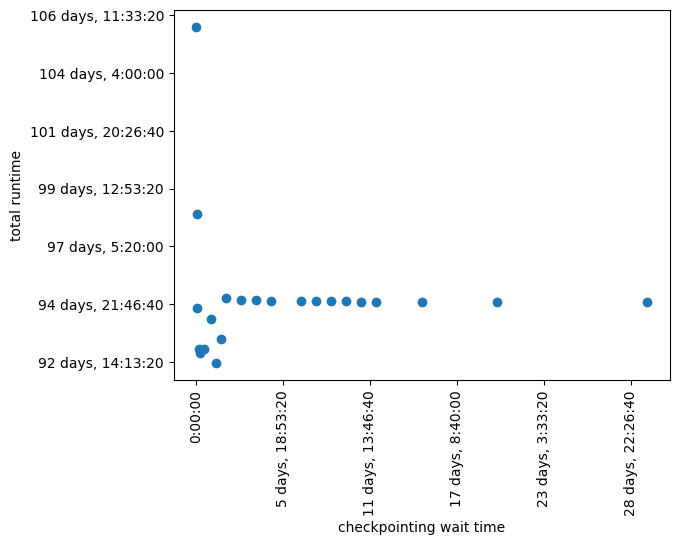

In [ ]:
fig = plt.figure()                                                                                                                                                                                                                                                             
ax = fig.add_subplot(111)

ax.scatter(check_waits, runtimes)

def formatter(x, pos):
    d = timedelta(milliseconds=x)                                                                                                                                                                                                                                    
    return str(d) 

plt.xlabel("checkpointing wait time")
plt.ylabel("total runtime")

ax.xaxis.set_major_formatter(formatter)
plt.xticks(rotation=90)
ax.yaxis.set_major_formatter(formatter)
plt.show()

In [81]:
check_time = 300_000
check_wait = 1_800_000

df_host, df_server, df_service = get_output("two_failures", check_time, check_wait)
server_name = "1019"

df_task = df_server[df_server.server_name == server_name]
df_meta_task = df_meta[df_meta.id == server_name]

In [87]:
def calc_delayed_runtime(runtime, check_time, check_wait):
    total_checks = np.ceil(runtime / check_wait) - 1
    print(total_checks)
    return runtime + (check_time * total_checks)

expected_runtime = (df_meta_task["stop_time"] - df_meta_task["start_time"]).item() / timedelta(milliseconds=1)
expected_runtime = calc_delayed_runtime(expected_runtime, check_time, check_wait))

df_task["diff"] = df_task.uptime.diff()

df_task[df_task["diff"] != 0]

initial_runtime = df_task.timestamp.max() - df_task.timestamp.min() 

change_points = df_task[df_task["diff"] != 0]
num_changes = len(change_points)

total_runtime = 0

i = 1
while i < num_changes:
    print(i)
    intermediate_runtime = (change_points.timestamp.iloc[i] - change_points.timestamp.iloc[i-1] + timedelta(milliseconds = int(change_points.uptime.iloc[i-1]))) / timedelta(milliseconds=1)

    print(timedelta(milliseconds=intermediate_runtime))
    total_runtime += intermediate_runtime
    i += 2

final_runtime = (df_task.timestamp.max() - change_points.timestamp.iloc[i-1] + timedelta(milliseconds = int(change_points.uptime.iloc[i-1]))) / timedelta(milliseconds=1)
print(timedelta(milliseconds=final_runtime))

total_runtime += final_runtime

timedelta(milliseconds=total_runtime)

1
1 day, 0:00:00
3
2 days, 0:00:00
32 days, 0:15:00


/tmp/ipykernel_5508/1424569439.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_task["diff"] = df_task.uptime.diff()


datetime.timedelta(days=35, seconds=900)

In [71]:




print(runtime)


2592252000.0
1440.0


datetime.timedelta(days=35, seconds=252)

In [63]:
(df_meta["stop_time"] - df_meta["start_time"]).iloc[0]

Timedelta('30 days 00:04:12')